<a href="https://colab.research.google.com/github/lipchenko/machine_learning_lipchenko/blob/main/my_log_reg_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- **Сколько всего текстов в датасете?**

Всего текстов 1986.
- **Выведите количество текстов в каждой категории**

В категории хоккей 999, в категории космос 987

### **2. Анализ данных**

In [ ]:
print(f'Количество текстов в датасете : {len(data)}')
number = data['category'].value_counts()
print(number)
# Подсказка: используйте value_counts()

Количество текстов в датасете : 1986
category
0    999
1    987
Name: count, dtype: int64


**Вопрос:** Какая категория больше: хоккей или космос?

Больше текстов в категории хоккей - 999

### **3. Очистка текста**

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = text.strip()
    return text

data['clean_text'] = data['text'].apply(clean_text)

print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccallmksoldsegticom fred j mccall 
subject re vandalizing the sky
articleid mksolapr
organizat


### **4. Создание признаков (векторизация)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_text'])
print(f"Количество уникальных слов: {X.shape[1]}")

Количество уникальных слов: 28383


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

**Ответ**: было найдено 28383 слов

### **5. Разделение данных**

In [ ]:
from sklearn.model_selection import train_test_split

X = vectorizer.fit_transform(data['clean_text'])
y = data['category']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (1588, 28383)
Размер X_test: (398, 28383)
Размер y_train: (1588,)
Размер y_test: (398,)


### **6. Обучение модели**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Создание модели логистической регрессии
model = LogisticRegression(max_iter=1000)

# Обучение модели
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
#Создаем предсказание для тестовых данных

### **7. Оценка модели**

In [ ]:
from sklearn.metrics import accuracy_score
#вычисляем accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.1%}")
#выводим результат в процентах

Точность: 99.2%


**Вопрос:** Какая точность у вашей модели? Что это значит?

Ответ: у модели высокая точность (99.2%), она распределила почти все тексты правильно.

### **8. Анализ ошибок**

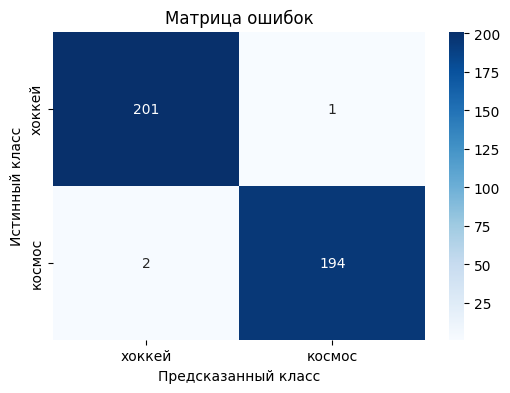

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
#создаем матрицу
cm = confusion_matrix(y_test, y_pred)

# визуализация
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['хоккей', 'космос'],
            yticklabels=['хоккей', 'космос'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

Ответ: только 2 текста были классифицированы как класс хоккея